In [117]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Optional: warnings filter (to keep notebook clean)
import warnings
warnings.filterwarnings("ignore")



In [118]:
import pandas as pd

# If your file is CSV
df = pd.read_csv("Desktop/project 2/project_2_dataset_excel.csv")

# If Excel
# df = pd.read_excel("Desktop/project 2/project_2_dataset_excel.csv")

df.head()


,CustomerID,Age,Gender,ItemPurchased,Category,PurchaseAmountUSD,Size,ReviewRating,DiscountApplied,PreviousPurchases,PaymentMethod,Annual_Income,Spending_Score,Purchase_Frequency
0,1,56,Male,Bag,Accessories,374.86,L,3,Yes,7,PayPal,94510,14,9
1,2,46,Male,Shoes,Home Decor,33.28,S,2,Yes,3,UPI,117668,98,3
2,3,32,Female,Laptop,Home Decor,117.45,S,4,Yes,13,UPI,80912,41,20
3,4,60,Male,Bag,Home Decor,356.05,M,2,No,14,PayPal,87164,100,18
4,5,25,Female,Laptop,Accessories,393.50,M,2,No,5,Cash,87035,52,20


In [119]:
# Handle missing values
df = df.dropna()

# Fill numeric columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical (string) columns with mode safely
for col in df.select_dtypes(include=['string']).columns:   # use 'string' instead of 'object'
    mode_val = df[col].mode()
    if not mode_val.empty:   # check if mode exists
        df[col] = df[col].fillna(mode_val[0])
# Encode Gender
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = ['Annual_Income','Spending_Score','Age','Purchase_Frequency']
df_scaled = scaler.fit_transform(df[features])


In [120]:
# Show first 10 rows of cleaned dataset
print(df.head(10))

# Or check dataset info
print(df.info())

# Or check summary statistics
print(df.describe())


   CustomerID  Age  Gender ItemPurchased     Category  PurchaseAmountUSD Size  \
0           1   56       0           Bag  Accessories             374.86    L   
1           2   46       0         Shoes   Home Decor              33.28    S   
2           3   32       1        Laptop   Home Decor             117.45    S   
3           4   60       0           Bag   Home Decor             356.05    M   
4           5   25       1        Laptop  Accessories             393.50    M   
5           6   38       1         Phone  Accessories             233.11    M   
6           7   56       0         Shoes  Accessories             352.06    S   
7           8   36       1       T-Shirt     Clothing             200.10   XL   
8           9   40       1         Watch  Electronics              88.36    M   
9          10   28       0      Football   Home Decor             205.09   XL   

   ReviewRating DiscountApplied  PreviousPurchases PaymentMethod  \
0             3             Yes         

In [121]:
# Show first 10 rows of scaled feature matrix
print(df_scaled[:10])

# Check shape (rows, columns)
print(df_scaled.shape)


[[ 0.23038497 -1.25775641  1.09681725 -0.25836392]
 [ 0.84910763  1.66578498  0.35578871 -1.29857655]
 [-0.13291888 -0.31804668 -0.68165126  1.64869256]
 [ 0.0341186   1.73539311  1.39322867  1.30195502]
 [ 0.03067205  0.06479803 -1.20037124  1.64869256]
 [ 1.15085448  0.13440616 -0.23703413 -0.60510147]
 [ 1.35134221  0.69127118  1.09681725  0.26174239]
 [ 1.40288017 -0.56167513 -0.38523984 -0.77847024]
 [ 1.37952912  0.4824468  -0.08882842  0.95521748]
 [ 0.92495846 -0.77049951 -0.97806268 -0.77847024]]
(3900, 4)


In [122]:
df.head()

,CustomerID,Age,Gender,ItemPurchased,Category,PurchaseAmountUSD,Size,ReviewRating,DiscountApplied,PreviousPurchases,PaymentMethod,Annual_Income,Spending_Score,Purchase_Frequency
0,1,56,0,Bag,Accessories,374.86,L,3,Yes,7,PayPal,94510,14,9
1,2,46,0,Shoes,Home Decor,33.28,S,2,Yes,3,UPI,117668,98,3
2,3,32,1,Laptop,Home Decor,117.45,S,4,Yes,13,UPI,80912,41,20
3,4,60,0,Bag,Home Decor,356.05,M,2,No,14,PayPal,87164,100,18
4,5,25,1,Laptop,Accessories,393.50,M,2,No,5,Cash,87035,52,20


In [123]:
df.head()

,CustomerID,Age,Gender,ItemPurchased,Category,PurchaseAmountUSD,Size,ReviewRating,DiscountApplied,PreviousPurchases,PaymentMethod,Annual_Income,Spending_Score,Purchase_Frequency
0,1,56,0,Bag,Accessories,374.86,L,3,Yes,7,PayPal,94510,14,9
1,2,46,0,Shoes,Home Decor,33.28,S,2,Yes,3,UPI,117668,98,3
2,3,32,1,Laptop,Home Decor,117.45,S,4,Yes,13,UPI,80912,41,20
3,4,60,0,Bag,Home Decor,356.05,M,2,No,14,PayPal,87164,100,18
4,5,25,1,Laptop,Accessories,393.50,M,2,No,5,Cash,87035,52,20


In [124]:
print(df['Gender'].value_counts())


Gender
0    1963
1    1937
Name: count, dtype: int64


In [125]:
# -------------------------------
# Step 3: Feature Selection
# -------------------------------

# Select relevant features
selected_features = ['Annual_Income', 'Spending_Score', 'Age']

# Create a new DataFrame with only these features
df_selected = df[selected_features]

print("Selected Features DataFrame:")
print(df_selected.head())

# Scale the selected features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_selected_scaled = scaler.fit_transform(df_selected)

print("\nFirst 5 rows of scaled selected features:")
print(df_selected_scaled[:5])
print("Shape of scaled data:", df_selected_scaled.shape)


Selected Features DataFrame:
   Annual_Income  Spending_Score  Age
0          94510              14   56
1         117668              98   46
2          80912              41   32
3          87164             100   60
4          87035              52   25

First 5 rows of scaled selected features:
[[ 0.23038497 -1.25775641  1.09681725]
 [ 0.84910763  1.66578498  0.35578871]
 [-0.13291888 -0.31804668 -0.68165126]
 [ 0.0341186   1.73539311  1.39322867]
 [ 0.03067205  0.06479803 -1.20037124]]
Shape of scaled data: (3900, 3)


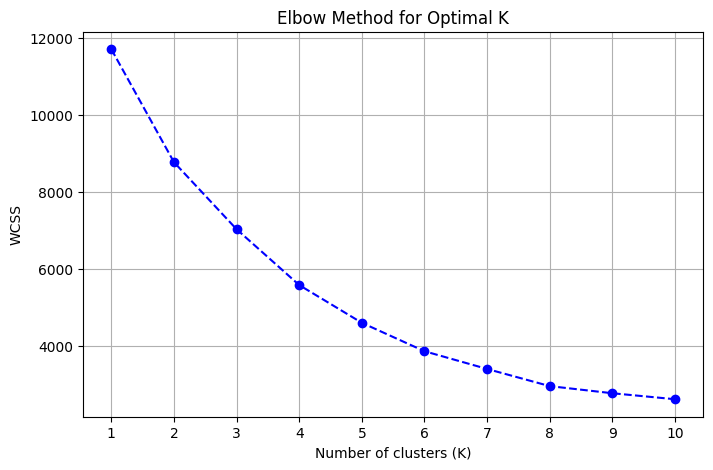

In [126]:
# -------------------------------
# Step 4: Finding Optimal Clusters (Elbow Method)
# -------------------------------

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Use the scaled data from Step 3 (df_selected_scaled)
wcss = []   # list to store WCSS values

# Test K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_selected_scaled)
    wcss.append(kmeans.inertia_)   # inertia_ = WCSS

# Plot WCSS vs K
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


Cluster labels assigned (first 10 rows):
   Annual_Income  Spending_Score  Age  Cluster
0          94510              14   56        3
1         117668              98   46        3
2          80912              41   32        0
3          87164             100   60        3
4          87035              52   25        0
5         128962              54   38        0
6         136466              70   56        3
7         138395              34   36        0
8         137521              64   40        0
9         120507              28   28        0


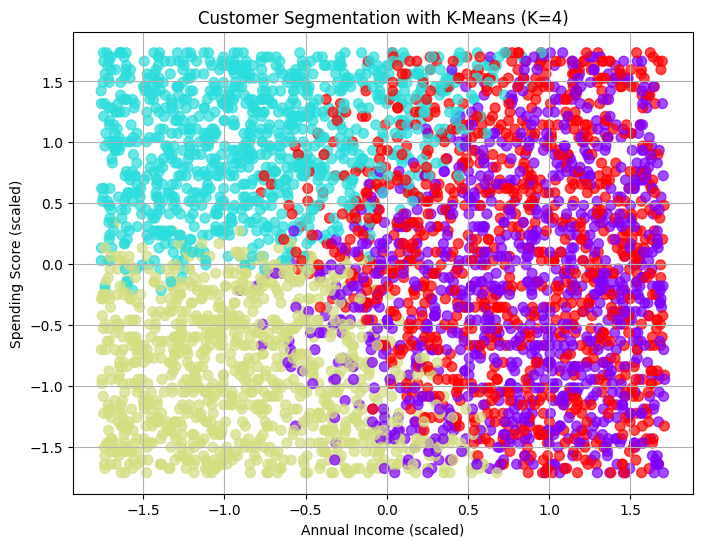

In [127]:
# -------------------------------
# Step 5: Apply K-Means Clustering
# -------------------------------

from sklearn.cluster import KMeans

# ✅ Choose K based on Elbow Method (example: K=4)
optimal_k = 4

# 1. Initialize KMeans
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# 2. Fit the model on scaled data
y_kmeans = kmeans.fit_predict(df_selected_scaled)

# 3. Add cluster labels back to the original DataFrame
df['Cluster'] = y_kmeans

# 4. Print sample output
print("Cluster labels assigned (first 10 rows):")
print(df[['Annual_Income','Spending_Score','Age','Cluster']].head(10))

# 5. Visualize clusters (2D plot using first two features)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_selected_scaled[:,0], df_selected_scaled[:,1],
            c=y_kmeans, cmap='rainbow', s=50, alpha=0.7)
plt.title(f'Customer Segmentation with K-Means (K={optimal_k})')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.grid(True)
plt.show()


In [128]:
# -------------------------------
# Step 6: Model Training
# -------------------------------

from sklearn.cluster import KMeans

# Use the optimal K from Step 4 (example: K=4)
optimal_k = 4

# 1. Train the K-Means model
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
kmeans.fit(df_selected_scaled)

# 2. Assign cluster labels to each customer
df['Cluster'] = kmeans.labels_

# 3. Print sample output
print("Cluster labels assigned (first 10 rows):")
print(df[['CustomerID','Annual_Income','Spending_Score','Age','Cluster']].head(10))

# 4. Check cluster distribution
print("\nCluster counts:")
print(df['Cluster'].value_counts())


Cluster labels assigned (first 10 rows):
   CustomerID  Annual_Income  Spending_Score  Age  Cluster
0           1          94510              14   56        3
1           2         117668              98   46        3
2           3          80912              41   32        0
3           4          87164             100   60        3
4           5          87035              52   25        0
5           6         128962              54   38        0
6           7         136466              70   56        3
7           8         138395              34   36        0
8           9         137521              64   40        0
9          10         120507              28   28        0

Cluster counts:
Cluster
0    1017
3     968
1     963
2     952
Name: count, dtype: int64


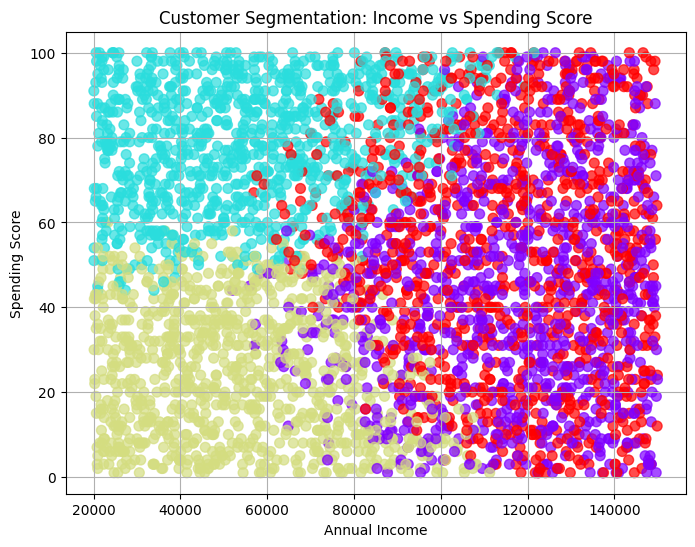

In [129]:
# -------------------------------
# Step 7: Visualization
# -------------------------------

import matplotlib.pyplot as plt

# Scatter plot of clusters (Income vs Spending Score)
plt.figure(figsize=(8,6))
plt.scatter(df['Annual_Income'], df['Spending_Score'],
            c=df['Cluster'], cmap='rainbow', s=50, alpha=0.7)

plt.title('Customer Segmentation: Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(True)
plt.show()


In [130]:
# -------------------------------
# Step 8: Cluster Interpretation
# -------------------------------

# Analyze clusters by calculating mean values for each feature
cluster_summary = df.groupby('Cluster')[['Annual_Income','Spending_Score','Age']].mean()

print("Cluster Summary (mean values):")
print(cluster_summary)

# Example interpretation logic
for cluster_id in cluster_summary.index:
    income = cluster_summary.loc[cluster_id, 'Annual_Income']
    spending = cluster_summary.loc[cluster_id, 'Spending_Score']
    age = cluster_summary.loc[cluster_id, 'Age']

    print(f"\nCluster {cluster_id} Analysis:")
    if income > df['Annual_Income'].mean() and spending > df['Spending_Score'].mean():
        print("→ High income, high spending customers (Premium Segment)")
    elif income < df['Annual_Income'].mean() and spending < df['Spending_Score'].mean():
        print("→ Low income, low spending customers (Budget Segment)")
    else:
        print("→ Moderate customers (Middle Segment)")


Cluster Summary (mean values):
         Annual_Income  Spending_Score        Age
Cluster                                          
0        116463.875123       44.992134  28.961652
1         56346.421599       78.609553  38.492212
2         53808.600840       24.321429  43.777311
3        114698.435950       52.610537  54.211777

Cluster 0 Analysis:
→ Moderate customers (Middle Segment)

Cluster 1 Analysis:
→ Moderate customers (Middle Segment)

Cluster 2 Analysis:
→ Low income, low spending customers (Budget Segment)

Cluster 3 Analysis:
→ High income, high spending customers (Premium Segment)


Overall Accuracy: 0.24358974358974358
Confusion Matrix:
 [[485 498 466 514]
 [532 465 486 454]
 [  0   0   0   0]
 [  0   0   0   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.25      0.33      1963
           1       0.48      0.24      0.32      1937
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0

    accuracy                           0.24      3900
   macro avg       0.24      0.12      0.16      3900
weighted avg       0.48      0.24      0.32      3900



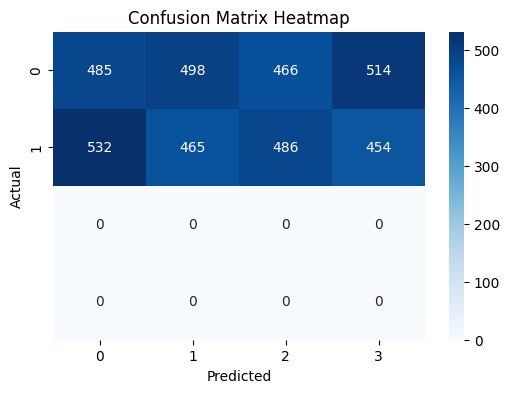

In [131]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Suppose you trained a model and have predictions
# y_true = actual labels (e.g., Pass/Fail, Gender, etc.)
# y_pred = predicted labels from your model

# Replace these with your actual variables
y_true = df['Gender']   # or another target column
y_pred = df['Cluster']  # or model predictions

# Overall Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Overall Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report (Precision, Recall, F1-score)
print("Classification Report:\n", classification_report(y_true, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_true))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()


Encoded columns: Index(['CustomerID', 'Age', 'Gender', 'ItemPurchased', 'Category',
       'PurchaseAmountUSD', 'Size', 'ReviewRating', 'DiscountApplied',
       'PreviousPurchases', 'PaymentMethod', 'Annual_Income', 'Spending_Score',
       'Purchase_Frequency'],
      dtype='str')
Overall Accuracy: 1.0
Confusion Matrix:
 [[389   0]
 [  0 391]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       389
           1       1.00      1.00      1.00       391

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780



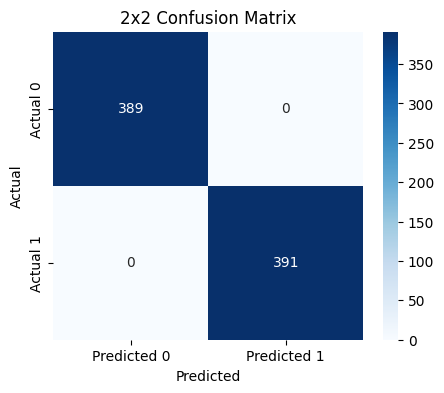

In [142]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load dataset
# -------------------------------
df = pd.read_csv("Desktop/project 2/project_2_dataset_excel.csv")

# -------------------------------
# Step 2: Encode categorical columns
# -------------------------------
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoded columns:", df.columns)

# -------------------------------
# Step 3: Define features (X) and target (y)
# -------------------------------
# Replace 'TargetColumn' with the actual target column in your dataset
y = df['Gender']                # target labels (binary: 0/1)
X = df.drop(columns=['Spending_Score']) # all other columns as features

# -------------------------------
# Step 4: Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# Step 5: Scale features
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Step 6: Train a model
# -------------------------------
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# -------------------------------
# Step 7: Predictions
# -------------------------------
y_pred = model.predict(X_test_scaled)

# -------------------------------
# Step 8: Evaluation
# -------------------------------
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Overall Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Predicted 0","Predicted 1"],
            yticklabels=["Actual 0","Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("2x2 Confusion Matrix")
plt.show()
